In [1]:
# ============================
# Cell 0: Imports + user settings
# ============================
# You only analyze ONE spaxel (x0,y0).
# Fiducial MDEG is 8 (per your request).
# We define line windows as:
#   full  : ±5 Å
#   inner : ±2.5 Å
#   edge  : full minus inner
#
# Units:
# - All integrated fluxes will be "cube units * Å" (because we sum flux * dλ).
# - Ratios are dimensionless.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# ---- Spaxel of interest (center)
x0, y0 = 218-5, 218-25

# ---- MDEGs to compare (fiducial = 8)
MDEGS = [8, 12, 14, 16, 20, 23]
FID_MDEG = 8

# ---- Window definitions
HALF_FULL  = 5.0   # ±5 Å integration window
HALF_INNER = 2.5   # ±2.5 Å inner core
# edge is the remainder of full outside inner

# ---- Line centers you provided (Å)
LINES = {
    "Hb":       4861.35,
    "OIII5007": 5006.84,
    "Ha":       6562.79,
    "NII6583":  6583.45,
    "SII6716":  6716.31,  
    "ArIII7136":7135.79,
    "OII7319":  7318.92,
    "SIII9069": 9068.60,
}

# ---- Run folder naming pattern in your pwd
# Adjust prefix if needed.
RUN_TEMPLATE = "IC3392_v3tk_9100_mask_uptoCONT_MDEG{mdeg}"

# ---- Candidate file name patterns inside each run folder
# We'll locate line cube for each MDEG.
LINE_CUBE_SUFFIX = "_line_cube.fits"

# ---- For denominators (fiducial only):
# 1) fiducial continuum cube (CONT cube)
# 2) original/raw cube (ORIG cube)
#
# If the auto-finder fails, you can set these manually later.


In [2]:
# ============================
# Cell 1 (UPDATED): Locate required FITS files + set fixed ORIG cube path
# ============================
# We find:
# - line_cube for each MDEG (must exist)
# - fiducial cont_cube for MDEG=8 (preferred; for continuum denominator)
# - original cube (raw): FIXED absolute path you provided
#
# Notes:
# - line cubes are expected at:
#     ./<RUNID>/<RUNID>_line_cube.fits
# - cont cube is searched only inside fiducial run folder (MDEG=8) using a few common names.
# - ORIG cube is fixed (no auto-detect).

from pathlib import Path

# ---- Fixed original cube path (as you specified)
fid_orig_path = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")
if not fid_orig_path.exists():
    raise FileNotFoundError(f"Fixed ORIG cube not found at:\n  {fid_orig_path}")

# ---- Helper to find a file inside a run folder
def find_file_in_run(run_dir: Path, patterns):
    """Return the first existing file in run_dir matching any pattern in `patterns`."""
    for pat in patterns:
        cand = run_dir / pat
        if cand.exists():
            return cand
    return None

# ---- Locate line cubes for each MDEG
line_paths = {}
missing = []
for mdeg in MDEGS:
    run_id = RUN_TEMPLATE.format(mdeg=mdeg)
    run_dir = Path.cwd() / run_id
    line_fp = run_dir / f"{run_id}{LINE_CUBE_SUFFIX}"
    if line_fp.exists():
        line_paths[mdeg] = line_fp
    else:
        missing.append(mdeg)

print("Found line cubes for MDEGs:", sorted(line_paths.keys()))
if missing:
    print("WARNING: missing line cubes for MDEGs:", missing)
    print("They will be skipped unless you add the runs / fix names.")

available_mdegs = sorted(line_paths.keys())
if FID_MDEG not in available_mdegs:
    raise RuntimeError(f"Fiducial MDEG={FID_MDEG} line cube not found. Cannot proceed.")

# ---- Locate fiducial CONT cube (for continuum denominator)
fid_run_id = RUN_TEMPLATE.format(mdeg=FID_MDEG)
fid_dir = Path.cwd() / fid_run_id

cont_candidates = [
    f"{fid_run_id}_cont_cube.fits",
    f"{fid_run_id}_CONT_cube.fits",
    f"{fid_run_id}_cont_cube.fits.gz",
    f"{fid_run_id}_cont.fits",
]
fid_cont_path = find_file_in_run(fid_dir, cont_candidates)

print("\nFiducial CONT cube:", fid_cont_path)
print("Fixed ORIG cube:", fid_orig_path)


Found line cubes for MDEGs: [8, 12, 14, 16, 20, 23]

Fiducial CONT cube: None
Fixed ORIG cube: /Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits


In [3]:
# ============================
# Cell 2 (FIXED): Open FITS, build wavelength grid, sanity checks
# ============================
# Fix for your error:
# - Some FITS files have data in a non-primary HDU (PRIMARY has data=None).
# - So we must *find the first HDU that actually contains a 3D cube*.
#
# This cell:
# 1) Opens each line cube (memmap)
# 2) Builds wavelength grid from the correct HDU header
# 3) Opens CONT (if present) and ORIG (fixed path) robustly, selecting the first 3D cube HDU
# 4) Verifies the spaxel (x0,y0) is in bounds
# Use rest-frame masks for line integration because your line list is rest wavelengths.
# We assume IC3392 redshift used in nGIST config: z = 0.005566

import numpy as np
from astropy.io import fits
from pathlib import Path

Z_SYS = 0.005566  # IC3392 assumed redshift

def find_first_cube_hdu(hdul, min_ndim=3):
    for i, h in enumerate(hdul):
        if h.data is None:
            continue
        if hasattr(h.data, "ndim") and h.data.ndim >= min_ndim:
            return i, h
    return None, None

def build_wave_from_header(hdr, nw):
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        raise ValueError("Missing CRVAL3 and/or CDELT3/CD3_3 in header.")
    pix = np.arange(nw, dtype=float) + 1.0
    return crval + (pix - crpix) * cdelt  # this is the cube's native wavelength axis (usually observed-frame)

# ----------------------------
# 1) Open line cubes + pick cube HDU
# ----------------------------
hdul_line = {}
line_hdu_idx = {}
line_data = {}

for mdeg in available_mdegs:
    hdul = fits.open(line_paths[mdeg], memmap=True)
    idx, hdu = find_first_cube_hdu(hdul, min_ndim=3)
    if hdu is None:
        raise RuntimeError(f"No 3D cube HDU found in line cube: {line_paths[mdeg]}")
    hdul_line[mdeg] = hdul
    line_hdu_idx[mdeg] = idx
    line_data[mdeg] = hdu.data
    print(f"MDEG {mdeg}: HDU={idx} shape={line_data[mdeg].shape} file={line_paths[mdeg].name}")

# ----------------------------
# 2) Wavelength grid (LINE): observed + rest
# ----------------------------
fid_idx = line_hdu_idx[FID_MDEG]
fid_hdr = hdul_line[FID_MDEG][fid_idx].header
nw, ny, nx = line_data[FID_MDEG].shape

wave_line_obs  = build_wave_from_header(fid_hdr, nw)
wave_line_rest = wave_line_obs / (1.0 + Z_SYS)

# Choose the wavelength grid used downstream for masks/integration:
wave = wave_line_rest  # <-- everything below in your notebook will now be in rest-frame
dw_rest = float(np.nanmedian(np.diff(wave)))

print("\nLINE cube wave (obs):  ", wave_line_obs.min(), "to", wave_line_obs.max(), "Å")
print("LINE cube wave (rest): ", wave.min(), "to", wave.max(), "Å  (z=", Z_SYS, ")")
print("dw_rest ~", dw_rest, "Å/pixel")

# Optional sanity: where do rest lines land in observed frame?
print("\nSanity: observed-frame centers for your rest-frame line list:")
for lname, l0_rest in LINES.items():
    l0_obs = l0_rest * (1.0 + Z_SYS)
    print(f"  {lname:8s} rest={l0_rest:8.2f}  -> obs~{l0_obs:8.2f}")

# ----------------------------
# 3) Spaxel bounds check
# ----------------------------
if not (0 <= x0 < nx and 0 <= y0 < ny):
    raise ValueError(f"Spaxel (x0,y0)=({x0},{y0}) outside cube bounds nx={nx}, ny={ny}.")

# ----------------------------
# 4) Open fiducial CONT cube (if present), build its rest-frame wave too
# ----------------------------
hdul_cont = None
cont_data = None
cont_idx = None
wave_cont_obs = None
wave_cont_rest = None

if fid_cont_path is not None:
    hdul_cont = fits.open(fid_cont_path, memmap=True)
    cont_idx, cont_hdu = find_first_cube_hdu(hdul_cont, min_ndim=3)
    if cont_hdu is None:
        print("WARNING: No 3D cube HDU found in CONT file (skipping CONT denominators):", fid_cont_path)
        hdul_cont = None
    else:
        cont_data = cont_hdu.data
        nwc = cont_data.shape[0]
        wave_cont_obs  = build_wave_from_header(hdul_cont[cont_idx].header, nwc)
        wave_cont_rest = wave_cont_obs / (1.0 + Z_SYS)
        print(f"CONT cube: HDU={cont_idx} shape={cont_data.shape} file={Path(fid_cont_path).name}")

# ----------------------------
# 5) Open ORIG cube (fixed path), build its rest-frame wave too
# ----------------------------
hdul_orig = fits.open(fid_orig_path, memmap=True)
orig_idx, orig_hdu = find_first_cube_hdu(hdul_orig, min_ndim=3)
if orig_hdu is None:
    raise RuntimeError(f"No 3D cube HDU found in ORIG cube: {fid_orig_path}")
orig_data = orig_hdu.data

nwo = orig_data.shape[0]
wave_orig_obs  = build_wave_from_header(hdul_orig[orig_idx].header, nwo)
wave_orig_rest = wave_orig_obs / (1.0 + Z_SYS)

print(f"ORIG cube: HDU={orig_idx} shape={orig_data.shape} file={Path(fid_orig_path).name}")
print("ORIG wave (obs): ", wave_orig_obs.min(), "to", wave_orig_obs.max())
print("ORIG wave (rest):", wave_orig_rest.min(), "to", wave_orig_rest.max())

# ----------------------------
# 6) Note on compatibility checks
# ----------------------------
# From here on, if you integrate ORIG, use wave_orig_rest with orig_spec.
# If you integrate LINE, use wave (which is wave_line_rest) with line_spec.
# If you reconstruct CONT via ORIG - LINE, do it on the same grid (rest-frame line grid).

MDEG 8: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits
MDEG 12: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits
MDEG 14: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG14_line_cube.fits
MDEG 16: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits
MDEG 20: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits
MDEG 23: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG23_line_cube.fits

LINE cube wave (obs):   4827.5 to 9150.0 Å
LINE cube wave (rest):  4800.77886483831 to 9099.353001195346 Å  (z= 0.005566 )
dw_rest ~ 1.2430810110927268 Å/pixel

Sanity: observed-frame centers for your rest-frame line list:
  Hb       rest= 4861.35  -> obs~ 4888.41
  OIII5007 rest= 5006.84  -> obs~ 5034.71
  Ha       rest= 6562.79  -> obs~ 6599.32
  NII6583  rest= 6583.45  -> obs~ 6620.09
  SII6716  rest= 6716.31  -> obs~ 

In [4]:
# ============================
# Cell 3: Integration masks + helper functions
# ============================
# For each line center λ0 we define:
#   full  mask: |λ-λ0| <= 5
#   inner mask: |λ-λ0| <= 2.5
#   edge  mask: full & (~inner)
#
# Integrated flux:
#   F = Σ flux(λ_i) * dw   over selected pixels
# This assumes constant dw (true for these cubes).

def masks_for_line(wave, center, half_full=5.0, half_inner=2.5):
    full  = (wave >= center - half_full)  & (wave <= center + half_full)
    inner = (wave >= center - half_inner) & (wave <= center + half_inner)
    edge  = full & (~inner)
    return full, inner, edge

def integrate_flux(spec, mask, dw):
    """Integrate spectrum over mask using simple sum*dw. spec is 1D array."""
    if mask.sum() == 0:
        return np.nan
    return float(np.nansum(spec[mask]) * dw)

# Precompute masks for each line
line_masks = {}
for lname, l0 in LINES.items():
    full, inner, edge = masks_for_line(wave, l0, HALF_FULL, HALF_INNER)
    line_masks[lname] = {"full": full, "inner": inner, "edge": edge}

# Quick check: print how many pixels in each region (depends on dw)
for lname in LINES:
    print(lname, {k: int(v.sum()) for k, v in line_masks[lname].items()})


Hb {'full': 8, 'inner': 4, 'edge': 4}
OIII5007 {'full': 8, 'inner': 4, 'edge': 4}
Ha {'full': 8, 'inner': 4, 'edge': 4}
NII6583 {'full': 8, 'inner': 4, 'edge': 4}
SII6716 {'full': 8, 'inner': 4, 'edge': 4}
ArIII7136 {'full': 8, 'inner': 4, 'edge': 4}
OII7319 {'full': 8, 'inner': 4, 'edge': 4}
SIII9069 {'full': 8, 'inner': 4, 'edge': 4}


In [5]:
# ============================
# Cell 4: Extract 1D spectra at the target spaxel
# ============================
# We extract:
# - line_spec[mdeg] : continuum-subtracted line cube spectrum at (y0,x0)
# - cont_spec_fid   : fiducial continuum model at (y0,x0)  (if cont cube exists)
# - orig_spec       : raw/original spectrum at (y0,x0)     (if orig cube exists)

line_spec = {}
for mdeg in available_mdegs:
    line_spec[mdeg] = np.asarray(line_data[mdeg][:, y0, x0], dtype=np.float64)

cont_spec_fid = None
if cont_data is not None:
    cont_spec_fid = np.asarray(cont_data[:, y0, x0], dtype=np.float64)

orig_spec = None
if orig_data is not None:
    orig_spec = np.asarray(orig_data[:, y0, x0], dtype=np.float64)

print("Extracted spectra at (x,y) =", (x0, y0))
print("Line specs:", sorted(line_spec.keys()))
print("CONT available?", cont_spec_fid is not None)
print("ORIG available?", orig_spec is not None)

# ============================
# Cell 4B (NEW): Extract ORIG variance (STAT) at spaxel and rebin to LINE grid
# ============================
# Assumptions:
# - ORIG cube has an extension named 'STAT' containing VARIANCE (same shape as flux cube).
# - Variance is variance of flux density per wavelength pixel.
# - We'll rebin variance to the LINE wavelength grid (rest-frame) in a variance-conserving way.

import numpy as np
from astropy.io import fits

# ---- 1) Grab STAT cube robustly
def get_stat_cube(hdul):
    # Prefer EXTNAME='STAT'
    for h in hdul:
        if h.name is not None and str(h.name).strip().upper() == "STAT":
            if h.data is not None and getattr(h.data, "ndim", 0) >= 3:
                return h.data, h.header
    # Fall back: second HDU (index 1) if it looks like a cube
    if len(hdul) > 1 and hdul[1].data is not None and getattr(hdul[1].data, "ndim", 0) >= 3:
        return hdul[1].data, hdul[1].header
    raise RuntimeError("Could not find a 3D STAT variance cube in ORIG FITS.")

stat_cube, stat_hdr = get_stat_cube(hdul_orig)
stat_spec_orig = np.asarray(stat_cube[:, y0, x0], dtype=np.float64)

print("STAT cube shape:", stat_cube.shape)
print("stat_spec_orig NaN frac:", np.mean(~np.isfinite(stat_spec_orig)))

# ---- 2) Use REST-frame wavelength grids consistently
# You already built these in Cell 2:
#   wave_line_rest = wave   (you set wave = wave_line_rest)
#   wave_orig_rest = wave_orig_rest
#
# We'll explicitly define them here:
wave_line_rest = wave  # LINE rest grid (from Cell 2)
wave_orig_rest_local = wave_orig_rest  # ORIG rest grid (from Cell 2)

# ---- 3) Variance-conserving rebin: propagate variance in integrated-flux space
def variance_conserving_rebin_1d(w_in, var_in, w_out):
    """
    Rebin variance of flux density var_in(w_in) -> var_out(w_out) in a way consistent
    with flux-conserving rebin of flux density.

    Treat each input pixel as contributing integrated flux:
      flux_i = f_i * dλ_i
    with variance:
      Var(flux_i) = Var(f_i) * dλ_i^2

    For each output bin, integrated flux is sum of overlapping input contributions,
    so integrated variance is summed similarly (assuming independence).
    Then convert back to variance of flux density:
      var_out = Var(flux_out_bin) / dλ_out^2
    """
    w_in  = np.asarray(w_in, float)
    var_in = np.asarray(var_in, float)
    w_out = np.asarray(w_out, float)

    # Ensure increasing
    in_rev  = w_in[1]  < w_in[0]
    out_rev = w_out[1] < w_out[0]
    if in_rev:
        w_in = w_in[::-1]
        var_in = var_in[::-1]
    if out_rev:
        w_out = w_out[::-1]

    # Replace non-finite variance with large numbers? Better: set to NaN and ignore later.
    # Here we set NaNs to median finite variance to avoid breaking interpolation.
    v = var_in.copy()
    finite = np.isfinite(v)
    if finite.sum() >= 1:
        v[~finite] = np.nanmedian(v[finite])
    else:
        v[:] = np.nan

    # Build edges
    e_in = np.empty(w_in.size + 1, float)
    e_in[1:-1] = 0.5 * (w_in[:-1] + w_in[1:])
    e_in[0]    = w_in[0]  - 0.5 * (w_in[1] - w_in[0])
    e_in[-1]   = w_in[-1] + 0.5 * (w_in[-1] - w_in[-2])

    e_out = np.empty(w_out.size + 1, float)
    e_out[1:-1] = 0.5 * (w_out[:-1] + w_out[1:])
    e_out[0]    = w_out[0]  - 0.5 * (w_out[1] - w_out[0])
    e_out[-1]   = w_out[-1] + 0.5 * (w_out[-1] - w_out[-2])

    # Integrated variance per input bin
    dlam_in = np.diff(e_in)
    var_flux_bin_in = v * (dlam_in ** 2)  # variance of integrated flux contribution

    # Cumulative integrated variance on edges
    cum_var = np.concatenate([[0.0], np.cumsum(var_flux_bin_in)])

    # Interpolate cumulative variance to output edges
    cum_var_out = np.interp(e_out, e_in, cum_var, left=cum_var[0], right=cum_var[-1])

    # Integrated variance per output bin
    var_flux_bin_out = np.diff(cum_var_out)

    # Convert to variance of flux density in output bins
    dlam_out = np.diff(e_out)
    var_out = var_flux_bin_out / (dlam_out ** 2)

    if out_rev:
        var_out = var_out[::-1]
    return var_out

# Rebin variance to LINE grid (rest-frame)
stat_spec_on_line = variance_conserving_rebin_1d(wave_orig_rest_local, stat_spec_orig, wave_line_rest)

print("stat_spec_on_line NaN frac:", np.mean(~np.isfinite(stat_spec_on_line)))

# ============================
# Cell 4C (REPLACE): Build fiducial continuum on LINE grid (REST-frame consistent)
# ============================
# Define:
#   orig_on_line = flux-conserving rebin of ORIG flux density onto LINE rest grid
#   cont_eff_fid = orig_on_line - line_spec[FID_MDEG]
#
# NOTE: This "continuum" is the implied continuum for the fiducial MDEG.
# (You won't use it to choose MDEG; it's just useful for sanity checks.)

import numpy as np

wave_line_rest = wave            # LINE rest grid
wave_orig_rest_local = wave_orig_rest  # ORIG rest grid

def fill_nans_1d(w, f):
    w = np.asarray(w, float)
    f = np.asarray(f, float)
    ok = np.isfinite(w) & np.isfinite(f)
    if ok.sum() < 2:
        return f
    f2 = f.copy()
    bad = ~ok
    f2[bad] = np.interp(w[bad], w[ok], f[ok])
    return f2

def flux_conserving_rebin_1d(w_in, f_in, w_out):
    w_in  = np.asarray(w_in, float)
    f_in  = np.asarray(f_in, float)
    w_out = np.asarray(w_out, float)

    in_rev  = w_in[1]  < w_in[0]
    out_rev = w_out[1] < w_out[0]
    if in_rev:
        w_in = w_in[::-1]
        f_in = f_in[::-1]
    if out_rev:
        w_out = w_out[::-1]

    f_in = fill_nans_1d(w_in, f_in)

    e_in = np.empty(w_in.size + 1, float)
    e_in[1:-1] = 0.5 * (w_in[:-1] + w_in[1:])
    e_in[0]    = w_in[0]  - 0.5 * (w_in[1] - w_in[0])
    e_in[-1]   = w_in[-1] + 0.5 * (w_in[-1] - w_in[-2])

    e_out = np.empty(w_out.size + 1, float)
    e_out[1:-1] = 0.5 * (w_out[:-1] + w_out[1:])
    e_out[0]    = w_out[0]  - 0.5 * (w_out[1] - w_out[0])
    e_out[-1]   = w_out[-1] + 0.5 * (w_out[-1] - w_out[-2])

    dlam_in = np.diff(e_in)
    flux_bin_in = f_in * dlam_in
    cum = np.concatenate([[0.0], np.cumsum(flux_bin_in)])

    cum_out = np.interp(e_out, e_in, cum, left=cum[0], right=cum[-1])

    flux_bin_out = np.diff(cum_out)
    dlam_out = np.diff(e_out)
    f_out = flux_bin_out / dlam_out

    if out_rev:
        f_out = f_out[::-1]
    return f_out

orig_on_line = flux_conserving_rebin_1d(wave_orig_rest_local, orig_spec, wave_line_rest)
cont_eff_fid = orig_on_line - line_spec[FID_MDEG]

print("orig_on_line NaN frac:", np.mean(~np.isfinite(orig_on_line)))
print("cont_eff_fid NaN frac:", np.mean(~np.isfinite(cont_eff_fid)))

Extracted spectra at (x,y) = (213, 193)
Line specs: [8, 12, 14, 16, 20, 23]
CONT available? False
ORIG available? True
STAT cube shape: (3761, 438, 437)
stat_spec_orig NaN frac: 0.02100505184791279
stat_spec_on_line NaN frac: 0.0
orig_on_line NaN frac: 0.0
cont_eff_fid NaN frac: 0.0002891008962127783


In [6]:
# ============================
# Cell 5 (REPLACE): Full-window (±5 Å) flux + uncertainty from variance
# ============================
# We compute for each line and each MDEG:
#   F(mdeg) = ∫_{λ0±5Å} line_spec[mdeg](λ) dλ   on LINE rest grid
#   σF      = sqrt( Σ var(λ) * (dλ_bin)^2 )     using STAT variance rebinned to LINE grid
#
# Key point:
# - σF is independent of MDEG (same data); we compute it once per line.

import numpy as np
import pandas as pd

wave_line_rest = wave  # LINE rest grid
var_line = stat_spec_on_line  # variance on LINE rest grid

def bin_widths_from_wave(w):
    w = np.asarray(w, float)
    if w[1] < w[0]:
        w = w[::-1]
    e = np.empty(w.size + 1, float)
    e[1:-1] = 0.5 * (w[:-1] + w[1:])
    e[0]    = w[0]  - 0.5 * (w[1] - w[0])
    e[-1]   = w[-1] + 0.5 * (w[-1] - w[-2])
    return np.diff(e)

dlam_line = bin_widths_from_wave(wave_line_rest)
if wave_line_rest[1] < wave_line_rest[0]:
    # keep arrays aligned if wave is decreasing
    dlam_line = dlam_line[::-1]

def mask_full(wave_arr, center, half=5.0):
    return (wave_arr >= center - half) & (wave_arr <= center + half)

def integrate_flux_binwise(spec, mask, dlam):
    m = mask & np.isfinite(spec) & np.isfinite(dlam)
    if m.sum() < 1:
        return np.nan
    return float(np.nansum(spec[m] * dlam[m]))

def integrate_sigma_from_var(var_spec, mask, dlam):
    """
    Var(Σ f_i dλ_i) = Σ Var(f_i) * dλ_i^2  (assume independent pixels)
    """
    m = mask & np.isfinite(var_spec) & np.isfinite(dlam)
    if m.sum() < 1:
        return np.nan
    varF = np.nansum(var_spec[m] * (dlam[m] ** 2))
    return float(np.sqrt(varF))

# ---- Choose which lines you want to use for decision-making
# You can edit this list. I'd start with strong lines:
KEY_LINES = ["Hb", "OIII5007", "Ha", "NII6583", "SII6716"]

rows = []
for lname, l0 in LINES.items():
    mfull = mask_full(wave_line_rest, l0, HALF_FULL)
    sigmaF = integrate_sigma_from_var(var_line, mfull, dlam_line)

    for mdeg in available_mdegs:
        F = integrate_flux_binwise(line_spec[mdeg], mfull, dlam_line)
        rows.append({
            "line": lname,
            "mdeg": int(mdeg),
            "F_full": F,
            "sigmaF_full": sigmaF,
        })

df_full = pd.DataFrame(rows).sort_values(["line","mdeg"]).reset_index(drop=True)

# Add fiducial comparison columns
fid = df_full[df_full["mdeg"] == FID_MDEG][["line","F_full"]].rename(columns={"F_full":"F_fid"})
df_full = df_full.merge(fid, on="line", how="left")
df_full["dF_vs_fid"] = df_full["F_full"] - df_full["F_fid"]
df_full["frac_vs_fid"] = df_full["F_full"] / df_full["F_fid"] - 1.0
df_full["sig_vs_fid"] = np.abs(df_full["dF_vs_fid"]) / df_full["sigmaF_full"]

display(df_full[df_full["line"].isin(KEY_LINES)])

,line,mdeg,F_full,sigmaF_full,F_fid,dF_vs_fid,frac_vs_fid,sig_vs_fid
6,Ha,8,1648.397381,25.747838,1648.397381,0.000000,0.000000,0.000000
7,Ha,12,1650.018596,25.747838,1648.397381,1.621215,0.000984,0.062965
8,Ha,14,1656.942222,25.747838,1648.397381,8.544842,0.005184,0.331866
9,Ha,16,1658.914934,25.747838,1648.397381,10.517554,0.006380,0.408483
10,Ha,20,1652.350228,25.747838,1648.397381,3.952848,0.002398,0.153522
11,Ha,23,1649.659667,25.747838,1648.397381,1.262286,0.000766,0.049025
12,Hb,8,257.169113,21.828496,257.169113,0.000000,0.000000,0.000000
13,Hb,12,264.844120,21.828496,257.169113,7.675007,0.029844,0.351605
14,Hb,14,266.279088,21.828496,257.169113,9.109974,0.035424,0.417343
15,Hb,16,271.347410,21.828496,257.169113,14.178296,0.055132,0.649532


In [7]:
# # ============================
# # Cell 6: Plot absolute integrated line-cube flux vs MDEG
# # ============================
# # For each line:
# # - x-axis: MDEG
# # - y-axis: integrated flux from line cube at the target spaxel
# # - show curves for full/inner/edge
# #
# # This answers: "Does increasing MDEG change the recovered integrated flux?"

# def plot_abs_flux_per_line(df, line_name):
#     sub = df[df["line"] == line_name].copy()
#     sub = sub.sort_values("mdeg")

#     plt.figure(figsize=(8,4))
#     for region in ["full","inner","edge"]:
#         s2 = sub[sub["region"] == region]
#         plt.plot(s2["mdeg"], s2["F_linecube"], marker="o", label=region)

#     plt.axvline(FID_MDEG, linestyle="--", linewidth=1)
#     plt.xlabel("MDEG")
#     plt.ylabel("Integrated line-cube flux (cube units * Å)")
#     plt.title(f"{line_name}: absolute integrated flux at spaxel (x,y)=({x0},{y0})")
#     plt.legend()
#     plt.grid(alpha=0.2)
#     plt.show()

# for lname in LINES.keys():
#     plot_abs_flux_per_line(df, lname)

# ============================
# Cell 6B (NEW): Choose best MDEG via "plateau within noise"
# ============================
# Idea:
# - Compare adjacent MDEGs: |F(m_i) - F(m_{i-1})| / sigmaF
# - Pick the SMALLEST MDEG after which changes are consistently small (plateau).
#
# Because you're analyzing only ONE spaxel, we aggregate across KEY_LINES.

import numpy as np
import pandas as pd

mgrid = sorted(df_full["mdeg"].unique())

# Compute adjacent-step significance for each line
adj_rows = []
for lname in KEY_LINES:
    sub = df_full[df_full["line"] == lname].sort_values("mdeg")
    F = sub["F_full"].values
    s = sub["sigmaF_full"].values
    m = sub["mdeg"].values

    for i in range(1, len(m)):
        dF = F[i] - F[i-1]
        sig = np.abs(dF) / s[i]  # sigma is same per line anyway; using i is fine
        adj_rows.append({
            "line": lname,
            "mdeg_prev": int(m[i-1]),
            "mdeg_curr": int(m[i]),
            "dF_adj": dF,
            "sig_adj": sig,
        })

df_adj = pd.DataFrame(adj_rows)

display(df_adj)

# ---- Plateau rule (tune thresholds if you want)
# Requirement for adopting mdeg_curr:
#   For ALL later adjacent steps >= that point:
#     median(sig_adj across KEY_LINES) <= MED_THR  AND  max(sig_adj across KEY_LINES) <= MAX_THR
MED_THR = 0.5
MAX_THR = 1.0

candidates = []
for cut in mgrid:
    # consider all adjacent steps with mdeg_prev >= cut
    later = df_adj[df_adj["mdeg_prev"] >= cut]
    if later.empty:
        continue

    # Aggregate across lines per step, then across steps
    step_stats = (later.groupby(["mdeg_prev","mdeg_curr"])["sig_adj"]
                       .agg(["median","max"])
                       .reset_index())
    ok = (step_stats["median"] <= MED_THR).all() and (step_stats["max"] <= MAX_THR).all()

    candidates.append({
        "candidate_mdeg": int(cut),
        "ok": bool(ok),
        "n_steps_checked": int(len(step_stats)),
        "worst_median": float(step_stats["median"].max()),
        "worst_max": float(step_stats["max"].max()),
    })

df_candidates = pd.DataFrame(candidates).sort_values("candidate_mdeg")
display(df_candidates)

# Pick smallest OK candidate
ok_cands = df_candidates[df_candidates["ok"]]
if len(ok_cands) == 0:
    best_mdeg = None
    print("No MDEG satisfies the current plateau thresholds.")
    print("Try loosening MED_THR/MAX_THR, or reduce KEY_LINES, or use multi-spaxel statistics.")
else:
    best_mdeg = int(ok_cands.iloc[0]["candidate_mdeg"])
    print(f"Recommended best MDEG (plateau): {best_mdeg}  "
          f"(MED_THR={MED_THR}, MAX_THR={MAX_THR}, KEY_LINES={KEY_LINES})")

,line,mdeg_prev,mdeg_curr,dF_adj,sig_adj
0,Hb,8,12,7.675007,0.351605
1,Hb,12,14,1.434967,0.065738
2,Hb,14,16,5.068322,0.232188
3,Hb,16,20,-8.574183,0.392798
4,Hb,20,23,-2.162126,0.099051
5,OIII5007,8,12,-4.539322,0.192494
6,OIII5007,12,14,6.586780,0.279319
7,OIII5007,14,16,-5.234830,0.221988
8,OIII5007,16,20,3.473484,0.147296
9,OIII5007,20,23,-2.542359,0.107811


,candidate_mdeg,ok,n_steps_checked,worst_median,worst_max
0,8,True,5,0.192494,0.392798
1,12,True,4,0.183302,0.392798
2,14,True,3,0.183302,0.392798
3,16,True,2,0.183302,0.392798
4,20,True,1,0.099051,0.107811


Recommended best MDEG (plateau): 8  (MED_THR=0.5, MAX_THR=1.0, KEY_LINES=['Hb', 'OIII5007', 'Ha', 'NII6583', 'SII6716'])


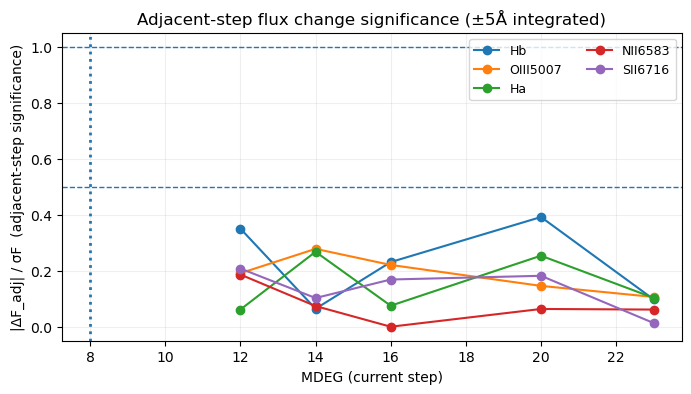

In [ ]:
# ============================
# Cell 6C (NEW): Visualize significance of adjacent changes per line
# ============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
for lname in KEY_LINES:
    sub = df_adj[df_adj["line"] == lname].sort_values("mdeg_curr")
    plt.plot(sub["mdeg_curr"], sub["sig_adj"], marker="o", label=lname)

plt.axhline(0.5, ls="--", lw=1)
plt.axhline(1.0, ls="--", lw=1)
if best_mdeg is not None:
    plt.axvline(best_mdeg, ls=":", lw=2)

plt.xlabel("MDEG (current step)")
plt.ylabel("|ΔF_adj| / σF  (adjacent-step significance)")
plt.title("Adjacent-step flux change significance (±5Å integrated)")
plt.grid(alpha=0.2)
plt.legend(ncol=2, fontsize=9)
plt.show()